In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("diabetes_data.csv", sep=";")
df = pd.get_dummies(df)
X = df.drop('class', axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [2]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [3]:
y_pred = nb_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9326923076923077
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.92      0.99      0.95        71

    accuracy                           0.93       104
   macro avg       0.94      0.90      0.92       104
weighted avg       0.93      0.93      0.93       104



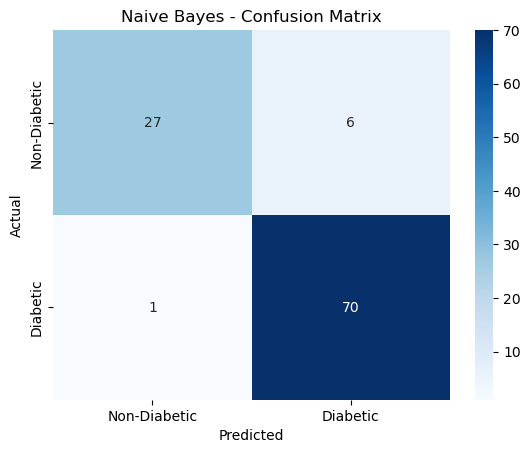

In [4]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic','Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'])
plt.title("Naive Bayes - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [5]:
cv_scores = cross_val_score(nb_model, X, y, cv=10, scoring='accuracy')
print("CV Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean()*100:.2f}%")

CV Scores: [0.82692308 0.90384615 0.92307692 0.94230769 0.71153846 0.90384615
 0.84615385 0.88461538 0.88461538 0.94230769]
Mean CV Accuracy: 87.69%


In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("="*40)
print("        PERFORMANCE METRICS")
print("="*40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, y_pred)*100:.2f}%")
print("="*40)

        PERFORMANCE METRICS
Accuracy  : 93.27%
Precision : 92.11%
Recall    : 98.59%
F1 Score  : 95.24%


In [7]:
import joblib

model = GaussianNB()
model.fit(X_train, y_train)

joblib.dump(model, "naive_bayes.pkl")
print("Saved successfully")

Saved successfully
